# Assignment 1:

# Step 1 – Copper-Plate Market Clearing (Single Hour)

## Market-Clearing Mechanism

The market-clearing problem maximizes social welfare:

$$
\max \left(
\sum_{d \in \mathcal{D}} U_d d_{d,t}
-
\sum_{i \in \mathcal{G}} C_i p_{i,t}
\right)
$$

subject to the power balance constraint:

$$
\sum_{i \in \mathcal{G}} p_{i,t}
+
\sum_{w \in \mathcal{W}} p_{w,t}
=
\sum_{d \in \mathcal{D}} d_{d,t}.
$$

The dual variable associated with the power balance constraint is the market-clearing price:

$$
\lambda_t.
$$

Under uniform pricing, all accepted generators and demands are settled at this price.

---

## Merit-Order Dispatch

Conventional generators are dispatched according to increasing marginal costs $C_i$.

The economic logic is:

- If $C_i < \lambda_t$ → the generator is **fully dispatched**.
- If $C_i = \lambda_t$ → the generator is **marginal** (partially dispatched).
- If $C_i > \lambda_t$ → the generator is **not dispatched**.

Renewable generators (wind) are modeled with zero marginal cost:

$$
C_w = 0,
$$

and are therefore dispatched up to their available capacity:

$$
0 \le p_{w,t} \le \bar{P}_{w,t}.
$$

---

## Welfare Decomposition

Social welfare is defined as:

$$
SW =
\sum_{d \in \mathcal{D}} U_d d_{d,t}
-
\sum_{i \in \mathcal{G}} C_i p_{i,t}.
$$

Producer profit for generator $i$:

$$
\Pi_i = (\lambda_t - C_i) p_{i,t}.
$$

Demand utility for consumer $d$:

$$
\text{Utility}_d = d_{d,t}(U_d - \lambda_t).
$$

Infra-marginal generators earn positive profits, while the marginal generator earns zero profit.

---

## KKT Conditions and Price Formation

The stationarity condition for each generator is:

$$
C_i - \lambda_t + \mu_i^{\max} - \mu_i^{\min} = 0,
$$

where:

- $\mu_i^{\max}$ is the multiplier of the upper bound constraint,
- $\mu_i^{\min}$ is the multiplier of the lower bound constraint.

Three cases arise:

1. **Marginal unit:**  
   $p_{i,t} > 0$ and not at a bound  
   $$C_i = \lambda_t.$$

2. **Infra-marginal unit (capacity constrained):**  
   $p_{i,t} = P_i^{\max}$  
   $$C_i < \lambda_t.$$

3. **Rejected unit:**  
   $p_{i,t} = 0$  
   $$C_i > \lambda_t.$$

Thus, the market-clearing price equals the marginal accepted bid, confirming the economic interpretation of the dual variable $\lambda_t$.

In [ ]:
import gurobipy as gp
from gurobipy import GRB
import pandas as pd
import os

# ============================================
# SETS
# ============================================

G = range(12)         # i ∈ 𝒢 (conventional generators)
W = [1,2,3,4,5,6]     # w ∈ 𝒲 (single aggregated wind unit)
D_set = [0]           # d ∈ 𝒟 (single aggregated demand)

# ============================================
# PARAMETERS
# ============================================

# Generator parameters
P_max = {
    0: 152, 1: 152, 2: 350, 3: 591, 4: 60, 5: 155,
    6: 155, 7: 400, 8: 400, 9: 300, 10: 310, 11: 350
}

C = {
    0: 13.32, 1: 13.32, 2: 20.70, 3: 20.93, 4: 26.11,
    5: 10.52, 6: 10.52, 7: 6.02, 8: 5.47, 9: 0.00,
    10: 10.52, 11: 10.89
}

# Demand parameters
D_t = 2650.5          # total system demand

# ============================================
# DEMAND DISTRIBUTION (FROM RTS DATA)
# ============================================

load_percent = {
    1:3.8, 2:3.4, 3:6.3, 4:2.6, 5:2.5,
    6:4.8, 7:4.4, 8:6.0, 9:6.1, 10:6.8,
    13:9.3, 14:6.8, 15:11.1, 16:3.5,
    18:11.7, 19:6.4, 20:4.5
}

# Convert to share
load_share = {n: load_percent[n]/100 for n in load_percent}

# Demand per node (demand blocks)
D_bus = {n: D_t * load_share[n] for n in load_share}

U_bus = {
    n: 8 + 200 * load_share[n]   # ~30–75 €/MWh
    for n in load_share
}


# ============================================
# WIND DATA IMPORT
# ============================================
wind_file = os.path.join("data", "processed", "wind_available_power_6_nodes_MW.csv")

wind_data = pd.read_csv(wind_file)

# specific hour (for example hour 18 peak denmand)
hour_star = 18

row = wind_data[wind_data["hour"] == hour_star]

P_w_bar = {
    1: row["wind_3"].values[0],
    2: row["wind_5"].values[0],
    3: row["wind_7"].values[0],
    4: row["wind_16"].values[0],
    5: row["wind_21"].values[0],
    6: row["wind_23"].values[0]
}
    
# ============================================
# REPORT INPUT SUMMARY
# ============================================

print("\n========== INPUT SUMMARY ==========")
print(f"Selected hour (wind peak): t = {hour_star}")
print(f"Total demand D_t: {D_t:.2f} MW")
print("\nWind availability per wind farm:")
for w in W:
    print(f"W{w}: {P_w_bar[w]:.2f} MW")

total_wind = sum(P_w_bar.values())
print(f"\nTotal wind availability: {total_wind:.2f} MW")
    

total_capacity = sum(P_max[i] for i in G)
print(f"Total conventional capacity Σ P_i^max: {total_capacity:.2f} MW")



========== INPUT SUMMARY ==========
Selected hour (wind peak): t = 18
Total demand D_t: 2650.50 MW

Wind availability per wind farm:
W1: 56.85 MW
W2: 64.45 MW
W3: 84.63 MW
W4: 33.48 MW
W5: 65.02 MW
W6: 81.37 MW

Total wind availability: 385.81 MW
Demand bid U_d: 100.00 €/MWh
Total conventional capacity Σ P_i^max: 3375.00 MW


In [30]:
# ============================================
# MODEL
# ============================================

model = gp.Model("CopperPlate_Market")

# Decision variables
p_i = model.addVars(G, lb=0,
                    ub=[P_max[i] for i in G],
                    name="p_i")

p_w = model.addVars(
    W,
    lb=0,
    ub=[P_w_bar[w] for w in W],
    name="p_w"
)

d_n = model.addVars(load_share.keys(), lb=0, name="d_n")

for n in load_share:
    model.addConstr(
        d_n[n] <= D_bus[n],
        name=f"demand_cap_{n}"
    )

# Objective: minimize (generation cost − utility)
model.setObjective(
    gp.quicksum(C[i] * p_i[i] for i in G)
    -
    gp.quicksum(U_bus[n] * d_n[n] for n in load_share),
    GRB.MINIMIZE
)

# Power balance
balance = model.addConstr(
    gp.quicksum(p_i[i] for i in G) +
    gp.quicksum(p_w[w] for w in W)
    == gp.quicksum(d_n[n] for n in load_share),
    name="power_balance"
)



model.optimize()



Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: AMD Ryzen 5 4600H with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
Thread count: 6 physical cores, 12 logical processors, using up to 12 threads

Optimize a model with 18 rows, 35 columns and 52 nonzeros (Min)
Model fingerprint: 0xbfae1636
Model has 28 linear objective coefficients
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [5e+00, 3e+01]
  Bounds range     [3e+01, 6e+02]
  RHS range        [7e+01, 3e+02]

Presolve removed 17 rows and 10 columns
Presolve time: 0.01s
Presolved: 1 rows, 25 columns, 25 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0   -5.8673588e+04   2.455865e+02   0.000000e+00      0s
       1   -4.1179865e+04   0.000000e+00   0.000000e+00      0s

Solved in 1 iterations and 0.01 seconds (0.00 work units)
Optimal objective -4.117986452e+04


In [31]:
# ============================================
# RESULTS
# ============================================

if model.status == GRB.OPTIMAL:

    print("\n========== MARKET CLEARING RESULTS ==========\n")

    # Market-clearing price λ_t
    lambda_t = balance.Pi
    print(f"Market clearing price λ_t: {lambda_t:.2f} €/MWh")

    print("\nWind production:")

    for w in W:
        print(f"W{w}: {p_w[w].X:.2f} MW")

    print("\nDemand served per node:\n")

    total_served = 0

    for n in load_share:
        val = d_n[n].X
        total_served += val
        print(f"Bus {n}: {val:.2f} MW at {U_bus[n]:.2f} €/MWh")

    print(f"\nTotal demand served: {total_served:.2f} MW")

    # Total operating cost
    total_cost = sum(C[i] * p_i[i].X for i in G)
    print(f"\nTotal operating cost: {total_cost:.2f} €")

    # Social welfare
    social_welfare = sum(U_bus[n] * d_n[n].X for n in load_share) - total_cost
    print(f"Social welfare: {social_welfare:.2f} €")

    # Producer profits
    print("\nProducer profits Π_i:")
    for i in G:
        profit_i = lambda_t * p_i[i].X - C[i] * p_i[i].X
        print(f"Unit {i+1}: {profit_i:.2f} €")

    # Wind profit
    print("\nWind profits:")

    for w in W:
        wind_profit = lambda_t * p_w[w].X
        print(f"W{w}: {wind_profit:.2f} €")

    # Demand utility
    utility_d = sum(U_bus[n] * d_n[n].X for n in load_share) - lambda_t * total_served
    print(f"Demand utility: {utility_d:.2f} €")

    # ============================================
    # KKT CHECK
    # ============================================

    print("\n========== KKT CHECK ==========\n")

    for i in G:
        print(f"Unit {i+1}:")
        print(f"  p_i,t = {p_i[i].X:.2f}")
        print(f"  Reduced cost = {p_i[i].RC:.6f}")


========== MARKET CLEARING RESULTS ==========

Market clearing price λ_t: 13.32 €/MWh

Wind production:
W1: 56.85 MW
W2: 64.45 MW
W3: 84.63 MW
W4: 33.48 MW
W5: 65.02 MW
W6: 81.37 MW

Demand served per node:

Bus 1: 100.72 MW at 15.60 €/MWh
Bus 2: 90.12 MW at 14.80 €/MWh
Bus 3: 166.98 MW at 20.60 €/MWh
Bus 4: 0.00 MW at 13.20 €/MWh
Bus 5: 0.00 MW at 13.00 €/MWh
Bus 6: 127.22 MW at 17.60 €/MWh
Bus 7: 116.62 MW at 16.80 €/MWh
Bus 8: 159.03 MW at 20.00 €/MWh
Bus 9: 161.68 MW at 20.20 €/MWh
Bus 10: 180.23 MW at 21.60 €/MWh
Bus 13: 246.50 MW at 26.60 €/MWh
Bus 14: 180.23 MW at 21.60 €/MWh
Bus 15: 294.21 MW at 30.20 €/MWh
Bus 16: 92.77 MW at 15.00 €/MWh
Bus 18: 310.11 MW at 31.40 €/MWh
Bus 19: 169.63 MW at 20.80 €/MWh
Bus 20: 119.27 MW at 17.00 €/MWh

Total demand served: 2515.32 MW

Total operating cost: 15722.66 €
Social welfare: 41179.86 €

Producer profits Π_i:
Unit 1: 0.00 €
Unit 2: 0.00 €
Unit 3: 0.00 €
Unit 4: 0.00 €
Unit 5: 0.00 €
Unit 6: 434.00 €
Unit 7: 434.00 €
Unit 8: 2920.00 €
U

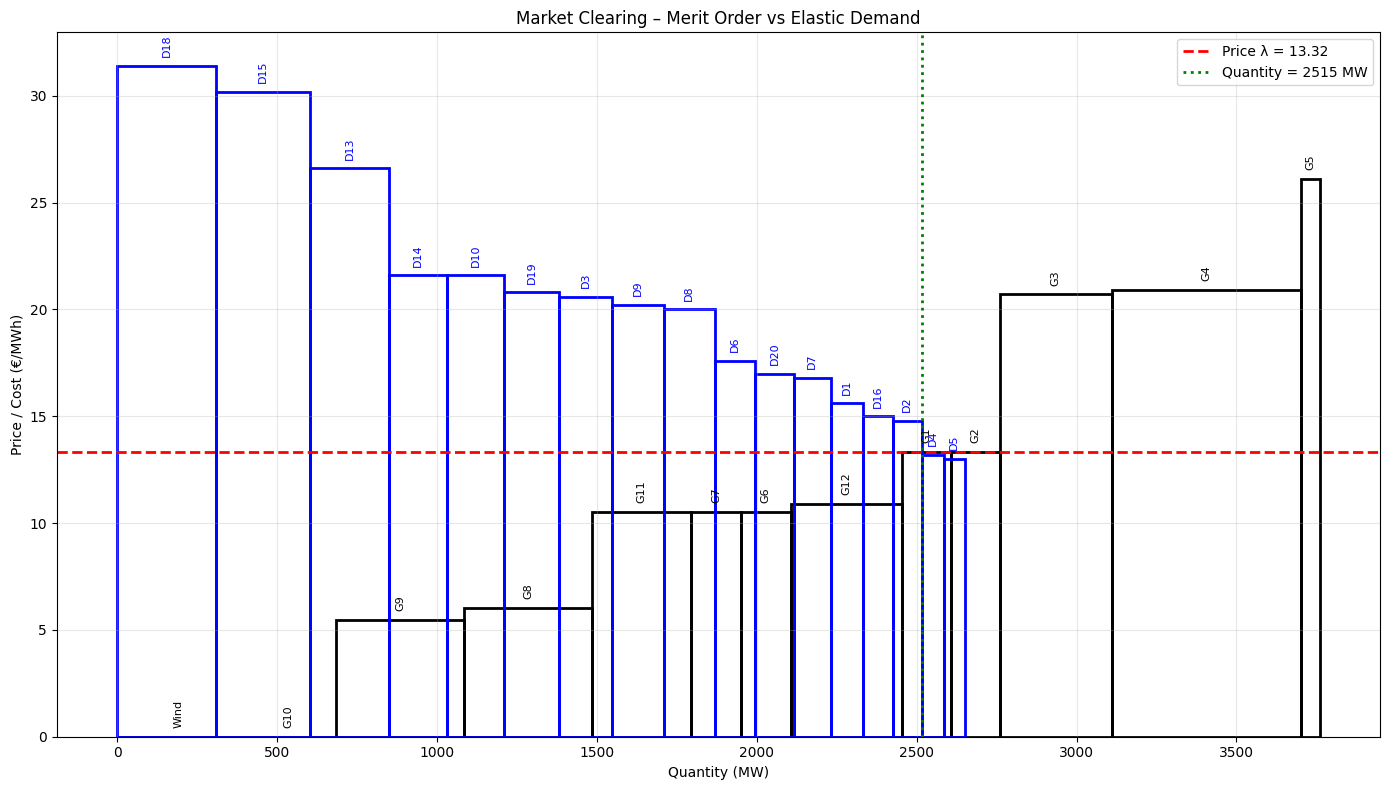

In [32]:
# ============================================
# PREPARE SUPPLY (SORTED)
# ============================================

gen_data = pd.DataFrame({
    "unit": [f"G{i}" for i in range(1, 13)],
    "Pmax": [152, 152, 350, 591, 60, 155, 155, 400, 400, 300, 310, 350],
    "cost": [13.32, 13.32, 20.70, 20.93, 26.11, 10.52, 10.52,
             6.02, 5.47, 0.00, 10.52, 10.89]
})

P_w_bar_total = sum(P_w_bar.values())

wind_block = pd.DataFrame({
    "unit": ["Wind"],
    "Pmax": [P_w_bar_total],
    "cost": [0.0]
})

supply_data = pd.concat([wind_block, gen_data], ignore_index=True)

# SORT SUPPLY (merit order)
supply_sorted = supply_data.sort_values("cost").reset_index(drop=True)


# ============================================
# PREPARE DEMAND (SORTED)
# ============================================

demand_data = pd.DataFrame({
    "bus": list(D_bus.keys()),
    "quantity": [D_bus[n] for n in D_bus],
    "price": [U_bus[n] for n in D_bus]
})

# SORT DEMAND (descending WTP)
demand_sorted = demand_data.sort_values("price", ascending=False).reset_index(drop=True)


# ============================================
# EQUILIBRIUM VALUES
# ============================================

D_served = sum(d_n[n].X for n in d_n)
lambda_t = balance.Pi


# ============================================
# PLOT
# ============================================

plt.figure(figsize=(14, 8))

# -------------------------------
# SUPPLY CURVE (HOLLOW BLACK)
# -------------------------------
cum_supply = 0

for i in range(len(supply_sorted)):
    cap = supply_sorted.loc[i, "Pmax"]
    cost = supply_sorted.loc[i, "cost"]
    unit = supply_sorted.loc[i, "unit"]

    plt.bar(
        cum_supply,
        cost,
        width=cap,
        align='edge',
        edgecolor='black',
        fill=False,
        linewidth=2
    )

    # LABEL (generator name)
    plt.text(
        cum_supply + cap/2,
        cost + 0.5,
        unit,
        ha='center',
        fontsize=8,
        rotation=90
    )

    cum_supply += cap


# -------------------------------
# DEMAND CURVE (HOLLOW BLUE)
# -------------------------------
cum_demand = 0

for i in range(len(demand_sorted)):
    q = demand_sorted.loc[i, "quantity"]
    p = demand_sorted.loc[i, "price"]
    bus = demand_sorted.loc[i, "bus"]

    plt.bar(
        cum_demand,
        p,
        width=q,
        align='edge',
        edgecolor='blue',
        fill=False,
        linewidth=2
    )

    # LABEL (bus)
    plt.text(
        cum_demand + q/2,
        p + 0.5,
        f"D{bus}",
        ha='center',
        fontsize=8,
        rotation=90,
        color='blue'
    )

    cum_demand += q


# -------------------------------
# EQUILIBRIUM LINES
# -------------------------------

plt.axhline(
    lambda_t,
    linestyle='--',
    linewidth=2,
    color='red',
    label=f"Price λ = {lambda_t:.2f}"
)

plt.axvline(
    D_served,
    linestyle=':',
    linewidth=2,
    color='green',
    label=f"Quantity = {D_served:.0f} MW"
)


# -------------------------------
# FINAL TOUCHES
# -------------------------------

plt.xlabel("Quantity (MW)")
plt.ylabel("Price / Cost (€/MWh)")
plt.title("Market Clearing – Merit Order vs Elastic Demand")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()